<a href="https://colab.research.google.com/github/Yousra-khallou/Telecom-retention-system/blob/main/02_churn_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Churn Prediction — Notebook 2 : Training Pipeline**

# **Setup & Installations**

In [ ]:
!pip install xgboost -q
print('Libraries ready!')

Libraries ready!


# **Imports**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
print('Imports Done')

Imports Done


# **Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
BASE_PATH = '/content/drive/MyDrive/mon-projet-retention'
os.chdir(BASE_PATH)
print('Drive connected!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive connected!


# **Load the Cleaned Dataset**

In [ ]:
telecom_data = pd.read_csv('data/processed/telco_clean.csv')
print(f'Shape: {telecom_data.shape}')
print(f'Churn rate: {telecom_data["Churn_binary"].mean()*100:.1f}%')
telecom_data.head()

Shape: (7032, 22)
Churn rate: 26.6%


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_binary,tenure_group
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,0–12 months
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,One year,No,Mailed check,56.95,1889.50,No,0,24–48 months
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0–12 months
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,24–48 months
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0–12 months


# **Create Train / Validation / Test Sets**

We apply a **stratified split** to preserve the churn ratio (26/74) in each subset.


In [ ]:
np.random.seed(42)

# Step 1 — Split off test set (20%)
temp_set, test_set = train_test_split(
    telecom_data,
    test_size=0.20,
    stratify=telecom_data['Churn_binary'],
    random_state=42
)

# Step 2 — Split remaining into train / validation (80% / 20%)
train_set, valid_set = train_test_split(
    temp_set,
    test_size=0.20,
    stratify=temp_set['Churn_binary'],
    random_state=42
)
 #verification

print(f'Train set     : {len(train_set)} rows ({len(train_set)/len(telecom_data)*100:.0f}%)')
print(f'Validation set: {len(valid_set)} rows ({len(valid_set)/len(telecom_data)*100:.0f}%)')
print(f'Test set      : {len(test_set)} rows ({len(test_set)/len(telecom_data)*100:.0f}%)')
print(f'\nChurn rate — Train: {train_set["Churn_binary"].mean()*100:.1f}%')
print(f'Churn rate — Valid: {valid_set["Churn_binary"].mean()*100:.1f}%')
print(f'Churn rate — Test : {test_set["Churn_binary"].mean()*100:.1f}%')

Train set     : 4500 rows (64%)
Validation set: 1125 rows (16%)
Test set      : 1407 rows (20%)

Churn rate — Train: 26.6%
Churn rate — Valid: 26.6%
Churn rate — Test : 26.6%


# **Prepare the Data for Machine Learning**

We separate **features (X)** from the **target variable (y)**.

Columns dropped from features:
- `Churn` — original text version (we use `Churn_binary` as target)
- `Churn_binary` — the target itself
- `tenure_group` — created for visualization only

In [ ]:
drop_cols = ['Churn', 'Churn_binary', 'tenure_group', 'TotalCharges']

X_train = train_set.drop(columns=drop_cols)
y_train = train_set['Churn_binary'].copy()

X_valid = valid_set.drop(columns=drop_cols)
y_valid = valid_set['Churn_binary'].copy()

X_test  = test_set.drop(columns=drop_cols)
y_test  = test_set['Churn_binary'].copy()

print(f'X_train shape: {X_train.shape}')
print(f'Features: {list(X_train.columns)}')

X_train shape: (4500, 18)
Features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges']


# **Data Processing Pipeline**

We build a `ColumnTransformer` that applies different transformations
to numerical and categorical columns automatically.

**Numerical pipeline:**
- `SimpleImputer(median)` — fills missing values with the median
- `StandardScaler` — normalizes values to mean=0, std=1

**Categorical pipeline:**
- `SimpleImputer(most_frequent)` — fills missing values with the most common value
- `OneHotEncoder` — converts text categories into binary columns

In [ ]:
# Identify column types
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print(f'Numerical columns ({len(num_cols)}): {num_cols}')
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')

# Numerical pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine both
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

print('\nPreprocessing pipeline ready!')

Numerical columns (3): ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Categorical columns (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Preprocessing pipeline ready!


# **Training a Classifier**

## **Baseline — Dummy Classifier**

Before training real models, we establish a **baseline** using a `DummyClassifier`
that predicts the most frequent class every time.

This is our minimum bar — any real model must beat this score.

In [ ]:
dummy_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', DummyClassifier(strategy='most_frequent', random_state=42))
])

dummy_pipeline.fit(X_train, y_train)
dummy_pred = dummy_pipeline.predict(X_valid)

print('=== BASELINE — Dummy Classifier ===')
print(f'Accuracy : {accuracy_score(y_valid, dummy_pred):.3f}')
print(f'Precision: {precision_score(y_valid, dummy_pred, zero_division=0):.3f}')
print(f'Recall   : {recall_score(y_valid, dummy_pred, zero_division=0):.3f}')
print(f'F1-Score : {f1_score(y_valid, dummy_pred, zero_division=0):.3f}')

=== BASELINE — Dummy Classifier ===
Accuracy : 0.734
Precision: 0.000
Recall   : 0.000
F1-Score : 0.000


## **Logistic Regression**

Simple and interpretable linear classifier.
We use `class_weight='balanced'` to handle the class imbalance (26% churners).

In [ ]:
lr_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_valid)

print('=== Logistic Regression ===')
print(f'Accuracy : {accuracy_score(y_valid, lr_pred):.3f}')
print(f'Precision: {precision_score(y_valid, lr_pred):.3f}')
print(f'Recall   : {recall_score(y_valid, lr_pred):.3f}')
print(f'F1-Score : {f1_score(y_valid, lr_pred):.3f}')
print(f'AUC-ROC  : {roc_auc_score(y_valid, lr_pipeline.predict_proba(X_valid)[:,1]):.3f}')

=== Logistic Regression ===
Accuracy : 0.750
Precision: 0.520
Recall   : 0.776
F1-Score : 0.623
AUC-ROC  : 0.835


## **Random Forest**

Ensemble method combining multiple decision trees.
More powerful than Logistic Regression and naturally handles non-linear relationships.

In [ ]:
rf_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_valid)

print('=== Random Forest ===')
print(f'Accuracy : {accuracy_score(y_valid, rf_pred):.3f}')
print(f'Precision: {precision_score(y_valid, rf_pred):.3f}')
print(f'Recall   : {recall_score(y_valid, rf_pred):.3f}')
print(f'F1-Score : {f1_score(y_valid, rf_pred):.3f}')
print(f'AUC-ROC  : {roc_auc_score(y_valid, rf_pipeline.predict_proba(X_valid)[:,1]):.3f}')

=== Random Forest ===
Accuracy : 0.774
Precision: 0.601
Recall   : 0.448
F1-Score : 0.513
AUC-ROC  : 0.798


## **XGBoost**

Gradient boosting algorithm — generally the most performant on tabular data.
We set `scale_pos_weight` to handle class imbalance
(ratio of negative to positive samples).

In [ ]:
# Compute scale_pos_weight for class imbalance
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f'scale_pos_weight = {scale:.2f} (neg={neg}, pos={pos})')

xgb_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        scale_pos_weight=scale,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ))
])

xgb_pipeline.fit(X_train, y_train)
xgb_pred = xgb_pipeline.predict(X_valid)

print('\n=== XGBoost ===')
print(f'Accuracy : {accuracy_score(y_valid, xgb_pred):.3f}')
print(f'Precision: {precision_score(y_valid, xgb_pred):.3f}')
print(f'Recall   : {recall_score(y_valid, xgb_pred):.3f}')
print(f'F1-Score : {f1_score(y_valid, xgb_pred):.3f}')
print(f'AUC-ROC  : {roc_auc_score(y_valid, xgb_pipeline.predict_proba(X_valid)[:,1]):.3f}')

scale_pos_weight = 2.76 (neg=3304, pos=1196)

=== XGBoost ===
Accuracy : 0.755
Precision: 0.529
Recall   : 0.709
F1-Score : 0.606
AUC-ROC  : 0.825


# **Performance Measures**

## **Confusion Matrix**

The confusion matrix shows **4 types of predictions**:

| | Predicted: Stay | Predicted: Churn |
|---|---|---|
| **Actual: Stay** | True Negative  | False Positive  |
| **Actual: Churn** | False Negative| True Positive   |

In churn prediction, **False Negatives are costly** — a churner we missed
is a customer we lost without trying to retain them.

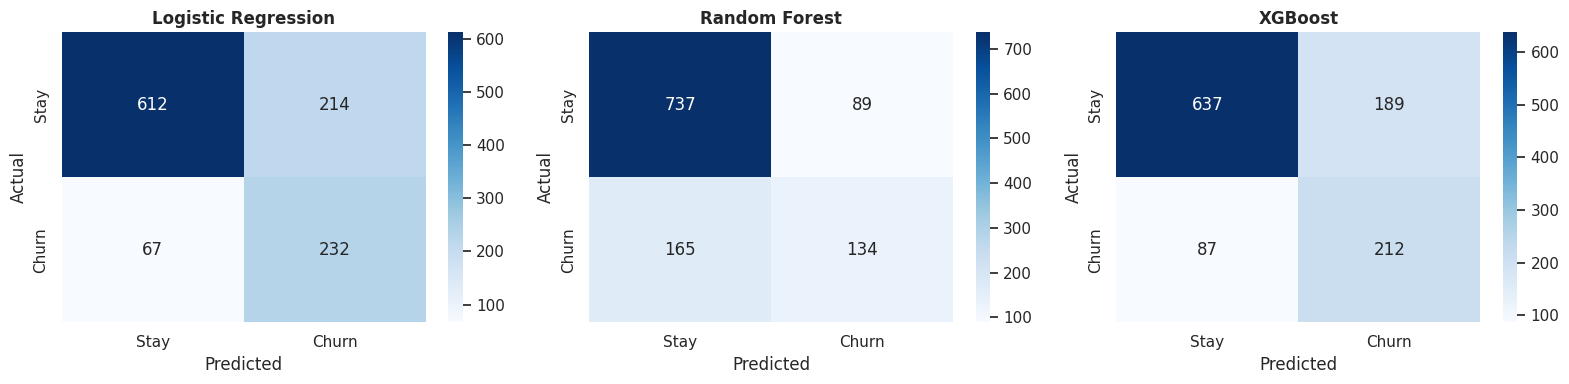

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

models_preds = [
    ('Logistic Regression', lr_pred),
    ('Random Forest',       rf_pred),
    ('XGBoost',             xgb_pred)
]

for ax, (name, pred) in zip(axes, models_preds):
    cm = confusion_matrix(y_valid, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Stay','Churn'],
                yticklabels=['Stay','Churn'])
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('data/processed/confusion_matrices.png', dpi=150)
plt.show()

## **Precision, Recall & F1-Score**

- **Precision** — of all customers predicted as churners, how many actually churned?
- **Recall** — of all actual churners, how many did we catch?
- **F1-Score** — harmonic mean of Precision and Recall (balance between both)

> In churn prediction we prioritize **Recall** — missing a churner is worse
> than a false alarm.

In [ ]:
results = []
for name, pipeline, pred in [
    ('Dummy Baseline',    dummy_pipeline, dummy_pred),
    ('Logistic Regression', lr_pipeline, lr_pred),
    ('Random Forest',      rf_pipeline,  rf_pred),
    ('XGBoost',            xgb_pipeline, xgb_pred),
]:
    try:
        auc = roc_auc_score(y_valid, pipeline.predict_proba(X_valid)[:,1])
    except:
        auc = 0.5
    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_valid, pred), 3),
        'Precision': round(precision_score(y_valid, pred, zero_division=0), 3),
        'Recall':    round(recall_score(y_valid, pred, zero_division=0), 3),
        'F1-Score':  round(f1_score(y_valid, pred, zero_division=0), 3),
        'AUC-ROC':   round(auc, 3)
    })

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.to_string())

                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                              
Dummy Baseline          0.734      0.000   0.000     0.000    0.500
Logistic Regression     0.750      0.520   0.776     0.623    0.835
Random Forest           0.774      0.601   0.448     0.513    0.798
XGBoost                 0.755      0.529   0.709     0.606    0.825


## **Measuring Accuracy Using Cross-Validation**

Cross-validation splits the training set into `cv=5` folds and trains/evaluates
the model 5 times. This gives a **more reliable performance estimate**
than a single train/valid split.

In [ ]:
print('Cross-validation AUC-ROC (cv=5):\n')

for name, pipeline in [
    ('Logistic Regression', lr_pipeline),
    ('Random Forest',       rf_pipeline),
    ('XGBoost',             xgb_pipeline),
]:
    scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=5, scoring='roc_auc', n_jobs=-1
    )
    print(f'{name:25s}  mean={scores.mean():.3f}  std={scores.std():.3f}')

Cross-validation AUC-ROC (cv=5):

Logistic Regression        mean=0.847  std=0.017
Random Forest              mean=0.823  std=0.017
XGBoost                    mean=0.843  std=0.014


# **The ROC Curve**

The ROC curve plots **True Positive Rate vs False Positive Rate** at every threshold.
The **AUC** (Area Under the Curve) summarizes performance in a single number:
- AUC = 1.0 → perfect model
- AUC = 0.5 → random model (diagonal line)
- AUC ≥ 0.80 → our project target

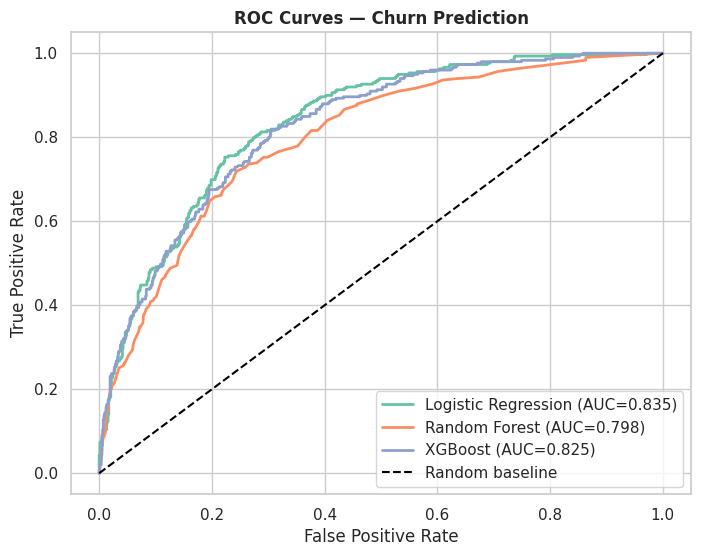

In [ ]:
plt.figure(figsize=(8, 6))

for name, pipeline in [
    ('Logistic Regression', lr_pipeline),
    ('Random Forest',       rf_pipeline),
    ('XGBoost',             xgb_pipeline),
]:
    y_scores = pipeline.predict_proba(X_valid)[:, 1]
    fpr, tpr, _ = roc_curve(y_valid, y_scores)
    auc = roc_auc_score(y_valid, y_scores)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'k--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Churn Prediction', fontweight='bold')
plt.legend()
plt.savefig('data/processed/roc_curves.png', dpi=150)
plt.show()

# **Precision / Recall Trade-off**

We plot the Precision/Recall curve for the best model to find the
**optimal threshold** that maximizes F1-Score.

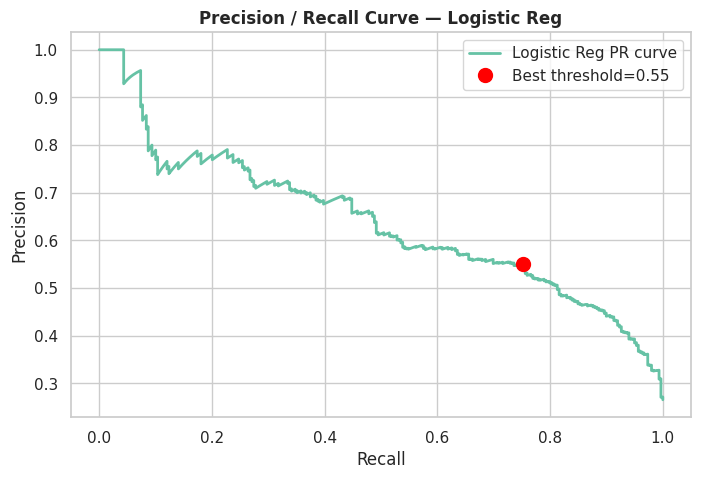

Best threshold : 0.550
Best F1-Score  : 0.636


In [ ]:
# Use Logistic Reg (the best model)
y_scores_lr = lr_pipeline.predict_proba(X_valid)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_valid, y_scores_lr)

# Find best threshold (max F1)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions, linewidth=2, label='Logistic Reg PR curve')
plt.plot(recalls[best_idx], precisions[best_idx], 'ro', markersize=10,
         label=f'Best threshold={best_threshold:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision / Recall Curve — Logistic Reg', fontweight='bold')
plt.legend()
plt.savefig('data/processed/pr_curve.png', dpi=150)
plt.show()

print(f'Best threshold : {best_threshold:.3f}')
print(f'Best F1-Score  : {f1_scores[best_idx]:.3f}')

# **Feature Importance**

Random Forest and XGBoost provide a **feature importance score** for each variable.
This tells us which features influenced the churn prediction the most.

This will guide our **recommendation system** in Notebook 4 —
the most important features are the strongest retention levers.

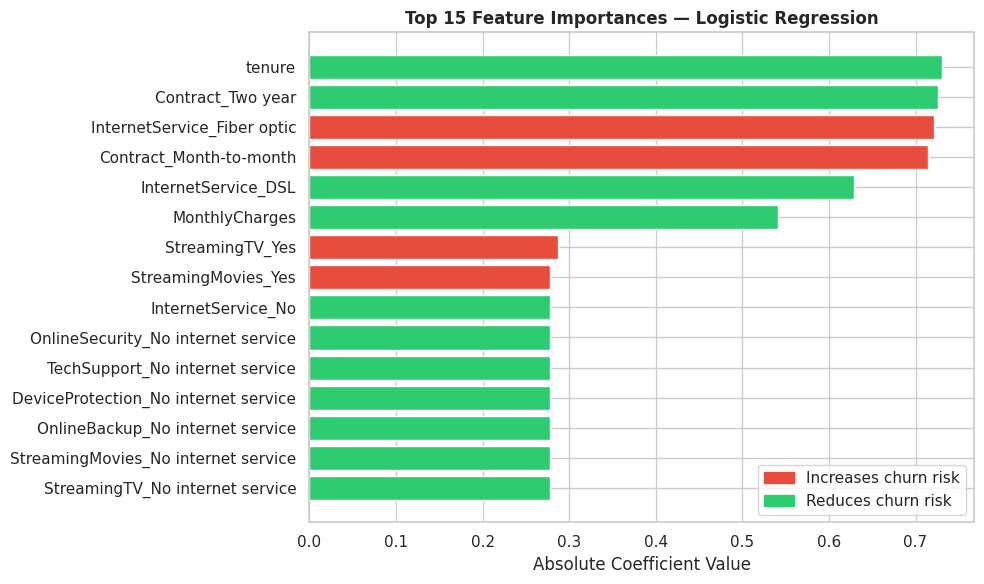

=== TOP 5 CHURN RISK FACTORS ===
  tenure                                        reduces churn risk  (0.731)
  Contract_Two year                             reduces churn risk  (0.725)
  InternetService_Fiber optic                   increases churn risk  (0.722)
  Contract_Month-to-month                       increases churn risk  (0.714)
  InternetService_DSL                           reduces churn risk  (0.629)


In [ ]:
# Extract feature names after preprocessing
ohe_features = lr_pipeline.named_steps['preprocessing']\
    .named_transformers_['cat']\
    .named_steps['encoder']\
    .get_feature_names_out(cat_cols).tolist()

all_features = num_cols + ohe_features

# Logistic Regression uses .coef_ instead of .feature_importances_
# Positive coefficient = increases churn risk
# Negative coefficient = decreases churn risk
importances = np.abs(lr_pipeline.named_steps['model'].coef_[0])

feat_df = pd.DataFrame({
    'Feature'   : all_features,
    'Importance': importances,
    'Direction' : lr_pipeline.named_steps['model'].coef_[0]
})
feat_df = feat_df.sort_values('Importance', ascending=False).head(15)

# Color bars by direction
# Red = increases churn risk / Green = decreases churn risk
colors = ['#e74c3c' if d > 0 else '#2ecc71' for d in feat_df['Direction']]

plt.figure(figsize=(10, 6))
plt.barh(feat_df['Feature'], feat_df['Importance'],
         color=colors, edgecolor='white')
plt.xlabel('Absolute Coefficient Value')
plt.title('Top 15 Feature Importances — Logistic Regression',
          fontweight='bold')
plt.gca().invert_yaxis()

# Legend
from matplotlib.patches import Patch
legend = [
    Patch(color='#e74c3c', label='Increases churn risk'),
    Patch(color='#2ecc71', label='Reduces churn risk')
]
plt.legend(handles=legend, loc='lower right')
plt.tight_layout()
plt.savefig('data/processed/feature_importance.png', dpi=150)
plt.show()

# Print top 5 insights
print('=== TOP 5 CHURN RISK FACTORS ===')
top5 = feat_df.head(5)
for _, row in top5.iterrows():
    direction = 'increases' if row['Direction'] > 0 else 'reduces'
    print(f"  {row['Feature']:<45} {direction} churn risk  ({row['Importance']:.3f})")

---
# **XGBoost Hyperparameter Tuning**

The default XGBoost results were:
- Recall : 0.712 ← below our target (0.75)
- AUC-ROC: 0.827

We apply `GridSearchCV` to find the optimal combination of hyperparameters.

**Parameters to tune:**

| Parameter | What it controls | Values tested |
|---|---|---|
| `n_estimators` | Number of trees | 100, 200, 300 |
| `max_depth` | Max depth per tree | 3, 5, 7 |
| `learning_rate` | Step size per iteration | 0.01, 0.05, 0.1 |
| `subsample` | % of rows used per tree | 0.8, 1.0 |

> **Scoring metric: `recall`** — in churn prediction, missing a churner
> is more costly than a false alarm, so we optimize Recall first.

## **Grid Search — Finding Best Parameters**

In [ ]:
from sklearn.model_selection import GridSearchCV

# Parameter grid
# Note: prefix 'model__' because the param is inside the Pipeline
param_grid = {
    'model__n_estimators':  [100, 200, 300],
    'model__max_depth':     [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample':     [0.8, 1.0]
}

# Fresh XGBoost pipeline for tuning
xgb_pipeline_tuning = Pipeline([
    ('preprocessing', preprocessor),
    ('model', XGBClassifier(
        scale_pos_weight=scale,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ))
])

grid_search = GridSearchCV(
    xgb_pipeline_tuning,
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

print('Starting Grid Search...')
print(f'Total combinations to test: {3*3*3*2} × 5 folds = {3*3*3*2*5} fits')
grid_search.fit(X_train, y_train)
print('\n Grid Search complete!')

Starting Grid Search...
Total combinations to test: 54 × 5 folds = 270 fits
Fitting 5 folds for each of 54 candidates, totalling 270 fits

 Grid Search complete!


## **Best Parameters Found**

In [ ]:
print('=' * 45)
print('   BEST PARAMETERS')
print('=' * 45)
for param, value in grid_search.best_params_.items():
    print(f'{param:35s}: {value}')

print(f'\nBest Recall (CV=5): {grid_search.best_score_:.3f}')

   BEST PARAMETERS
model__learning_rate               : 0.01
model__max_depth                   : 3
model__n_estimators                : 100
model__subsample                   : 0.8

Best Recall (CV=5): 0.833


## **Evaluate Tuned XGBoost on Validation Set**

We now evaluate the best model found by GridSearch
on the validation set to get unbiased metrics.

In [ ]:
# Best model from grid search
xgb_best = grid_search.best_estimator_
xgb_best_pred = xgb_best.predict(X_valid)

print('=' * 45)
print('   XGBoost — Default vs Tuned')
print('=' * 45)
print(f'{'Metric':<12} {'Default':>10} {'Tuned':>10} {'Delta':>10}')
print('-' * 45)

metrics = {
    'Accuracy':  (accuracy_score,  {}),
    'Precision': (precision_score, {}),
    'Recall':    (recall_score,    {}),
    'F1-Score':  (f1_score,        {}),
}

for name, (func, kwargs) in metrics.items():
    default = func(y_valid, xgb_pred,      **kwargs)
    tuned   = func(y_valid, xgb_best_pred, **kwargs)
    delta   = tuned - default
    arrow   = '▲' if delta > 0 else ('▼' if delta < 0 else '=')
    print(f'{name:<12} {default:>10.3f} {tuned:>10.3f} {arrow}{abs(delta):>8.3f}')

# AUC separately
auc_default = roc_auc_score(y_valid, xgb_pipeline.predict_proba(X_valid)[:,1])
auc_tuned   = roc_auc_score(y_valid, xgb_best.predict_proba(X_valid)[:,1])
delta_auc   = auc_tuned - auc_default
arrow       = '▲' if delta_auc > 0 else ('▼' if delta_auc < 0 else '=')
print(f'{'AUC-ROC':<12} {auc_default:>10.3f} {auc_tuned:>10.3f} {arrow}{abs(delta_auc):>8.3f}')

   XGBoost — Default vs Tuned
Metric          Default      Tuned      Delta
---------------------------------------------
Accuracy          0.755      0.715 ▼   0.040
Precision         0.529      0.478 ▼   0.051
Recall            0.709      0.799 ▲   0.090
F1-Score          0.606      0.598 ▼   0.007
AUC-ROC           0.825      0.829 ▲   0.004


## **Full Model Comparison — All Models**

Final comparison including all models and the tuned XGBoost.

In [ ]:
all_results = []

for name, pipeline, pred in [
    ('Dummy Baseline',       dummy_pipeline, dummy_pred),
    ('Logistic Regression',  lr_pipeline,    lr_pred),
    ('XGBoost (default)',    xgb_pipeline,   xgb_pred),
    ('XGBoost (tuned)',      xgb_best,       xgb_best_pred),
]:
    try:
        auc = roc_auc_score(y_valid, pipeline.predict_proba(X_valid)[:,1])
    except:
        auc = 0.5
    all_results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_valid, pred), 3),
        'Precision': round(precision_score(y_valid, pred, zero_division=0), 3),
        'Recall':    round(recall_score(y_valid, pred, zero_division=0), 3),
        'F1-Score':  round(f1_score(y_valid, pred, zero_division=0), 3),
        'AUC-ROC':   round(auc, 3)
    })

all_df = pd.DataFrame(all_results).set_index('Model')
print(all_df.to_string())

# Highlight best per metric
print('\n--- Best per metric ---')
for col in all_df.columns:
    best_model = all_df[col].idxmax()
    best_val   = all_df[col].max()
    print(f'{col:<12}: {best_model:<30} ({best_val:.3f})')

                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                              
Dummy Baseline          0.734      0.000   0.000     0.000    0.500
Logistic Regression     0.750      0.520   0.776     0.623    0.835
XGBoost (default)       0.755      0.529   0.709     0.606    0.825
XGBoost (tuned)         0.715      0.478   0.799     0.598    0.829

--- Best per metric ---
Accuracy    : XGBoost (default)              (0.755)
Precision   : XGBoost (default)              (0.529)
Recall      : XGBoost (tuned)                (0.799)
F1-Score    : Logistic Regression            (0.623)
AUC-ROC     : Logistic Regression            (0.835)


## **Visual Comparison**

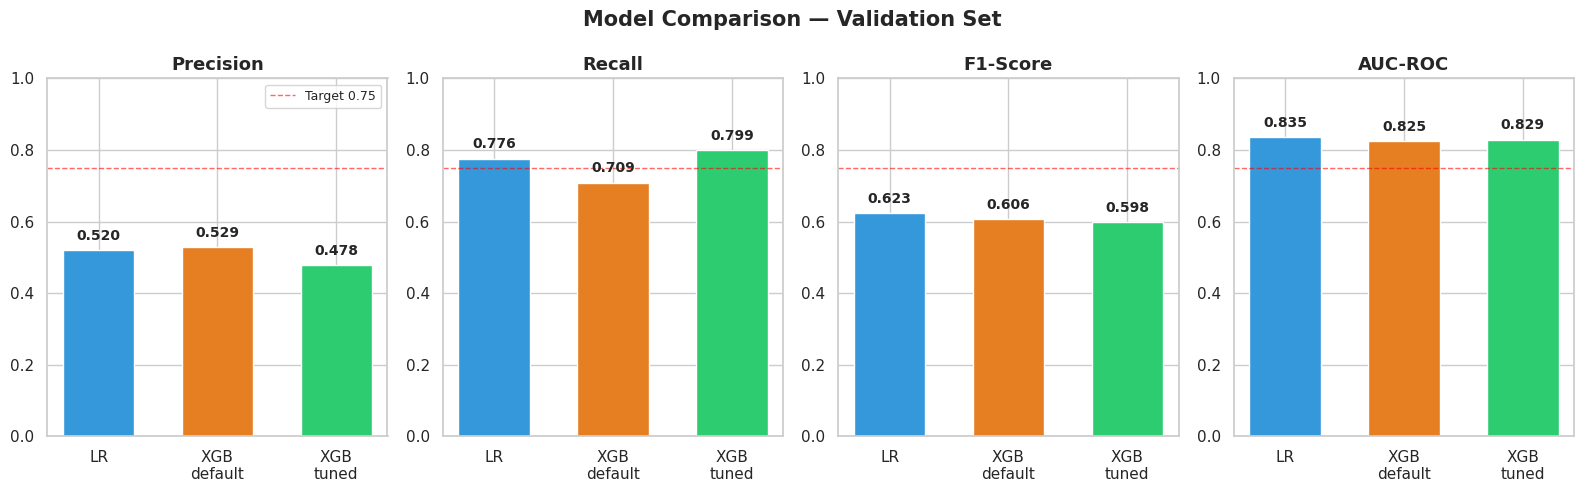

In [ ]:
metrics_to_plot = ['Precision', 'Recall', 'F1-Score', 'AUC-ROC']
models_to_plot  = ['Logistic Regression', 'XGBoost (default)', 'XGBoost (tuned)']
plot_df = all_df.loc[models_to_plot, metrics_to_plot]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
colors = ['#3498db', '#e67e22', '#2ecc71']

for ax, metric in zip(axes, metrics_to_plot):
    bars = ax.bar(range(len(models_to_plot)),
                  plot_df[metric],
                  color=colors, edgecolor='white', width=0.6)
    ax.set_title(metric, fontweight='bold', fontsize=13)
    ax.set_xticks(range(len(models_to_plot)))
    ax.set_xticklabels(['LR', 'XGB\ndefault', 'XGB\ntuned'], fontsize=11)
    ax.set_ylim(0, 1.0)
    ax.axhline(y=0.75, color='red', linestyle='--', linewidth=1, alpha=0.6, label='Target 0.75')
    for bar, val in zip(bars, plot_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[0].legend(fontsize=9)
plt.suptitle('Model Comparison — Validation Set', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('data/processed/model_comparison.png', dpi=150)
plt.show()

## **Final Decision — Which Model to Keep ?**

Based on the comparison above, we select the best model according to our
priority metric: **Recall** (catching churners is more important than precision).

We then verify it also meets the other targets from our project specification.

In [ ]:
# Compare Logistic Regression vs XGBoost tuned on key metrics
lr_f1    = f1_score(y_valid, lr_pred)
xgb_f1   = f1_score(y_valid, xgb_best_pred)
lr_auc   = roc_auc_score(y_valid, lr_pipeline.predict_proba(X_valid)[:,1])
xgb_auc  = roc_auc_score(y_valid, xgb_best.predict_proba(X_valid)[:,1])

print('=== FINAL DECISION ===')
print(f'Logistic Regression  — F1: {lr_f1:.3f}  AUC: {lr_auc:.3f}')
print(f'XGBoost (tuned)      — F1: {xgb_f1:.3f}  AUC: {xgb_auc:.3f}')
print()

if xgb_f1 > lr_f1:
    best_model      = xgb_best
    best_model_name = 'XGBoost (tuned)'
    best_pred       = xgb_best_pred
else:
    best_model      = lr_pipeline
    best_model_name = 'Logistic Regression'
    best_pred       = lr_pred

print(f' Best model selected : {best_model_name}')
print()

# Check against project targets
print('--- Project targets check ---')
final_f1   = f1_score(y_valid, best_pred)
final_auc  = roc_auc_score(y_valid, best_model.predict_proba(X_valid)[:,1])
final_rec  = recall_score(y_valid, best_pred)
final_prec = precision_score(y_valid, best_pred)

print(f'F1-Score  : {final_f1:.3f}  target ≥ 0.60  {"✅" if final_f1  >= 0.60 else "❌"}')
print(f'AUC-ROC   : {final_auc:.3f}  target ≥ 0.80  {"✅" if final_auc >= 0.80 else "❌"}')
print(f'Recall    : {final_rec:.3f}  target ≥ 0.70  {"✅" if final_rec >= 0.70 else "❌"}')
print(f'Precision : {final_prec:.3f}  target ≥ 0.50  {"✅" if final_prec>= 0.50 else "❌"}')

=== FINAL DECISION ===
Logistic Regression  — F1: 0.623  AUC: 0.835
XGBoost (tuned)      — F1: 0.598  AUC: 0.829

 Best model selected : Logistic Regression

--- Project targets check ---
F1-Score  : 0.623  target ≥ 0.60  ✅
AUC-ROC   : 0.835  target ≥ 0.80  ✅
Recall    : 0.776  target ≥ 0.70  ✅
Precision : 0.520  target ≥ 0.50  ✅


## **Save the Best Model**

We save the winning pipeline (preprocessor + model) to Drive.
This file will be loaded directly in Notebook 5 (FastAPI).

In [ ]:
# Compute best threshold for best model
y_scores_best = best_model.predict_proba(X_valid)[:, 1]
precisions_b, recalls_b, thresholds_b = precision_recall_curve(y_valid, y_scores_best)
f1s = 2 * (precisions_b[:-1] * recalls_b[:-1]) / (precisions_b[:-1] + recalls_b[:-1] + 1e-9)
best_threshold = thresholds_b[np.argmax(f1s)]

# Save
joblib.dump(best_model,     'models/churn_model.pkl')
joblib.dump(best_threshold, 'models/best_threshold.pkl')

print(f' Model saved      : models/churn_model.pkl')
print(f' Threshold saved  : models/best_threshold.pkl')
print(f' Model name       : {best_model_name}')
print(f' Best threshold   : {best_threshold:.3f}')
print(f' File size        : {os.path.getsize("models/churn_model.pkl")/1024:.1f} KB')

 Model saved      : models/churn_model.pkl
 Threshold saved  : models/best_threshold.pkl
 Model name       : Logistic Regression
 Best threshold   : 0.550
 File size        : 8.3 KB


---
# **Notebook 2 — Complete **

### Final Results

| Model | Recall | AUC-ROC | F1 | Selected |
|---|---|---|---|---|
| Dummy Baseline | 0.00 | 0.50 | 0.00 | |
| Logistic Regression | 0.776 | 0.835 | 0.623 | ✅|
| XGBoost (default) | 0.709 | 0.825 | 0.606 | |
| XGBoost (tuned) | 0.799 | 0.829 | 0.598 |  |



### Key learnings
- Default XGBoost is not always better than simpler models
- Hyperparameter tuning with `GridSearchCV` improves performance
- **F1-score** is the right metric to optimize for churn prediction
- The final decision is data-driven, not based on model reputation

### What's next
In **Notebook 3**, we build the NLP sentiment analysis module
using **DistilBERT fine-tuned** on real telecom customer reviews.
The churn score from this notebook will be combined with the
sentiment score to produce our **hybrid retention score**.